# Jz_2 Homodyne (N=2)
Notebook version with separate cells for:
- one-time setup/definitions
- parameters
- simulation
- save
- plotting


In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import importlib
import quantum_function2
importlib.reload(quantum_function2)

from quantum_function2 import *
from IPython.display import display, Markdown

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qutip import ket2dm, smesolve


In [2]:
# --- SAFETY SWITCH: esce subito se non abiliti esplicitamente ---
RUN_THIS_CELL = True   # metti True solo quando vuoi davvero eseguire

if not RUN_THIS_CELL:
    display(Markdown("Cell locked. Set `RUN_THIS_CELL = True` to run"))
    raise SystemExit

plt.rcParams["text.usetex"] = True
plt.rcParams.update({
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.size": 14,
    "axes.unicode_minus": False,
})


In [6]:
DEFAULT_EOPS = [
    ("Conc", concurrence_for_solver_general),
    ("Xi2_KU", xi_KU_solver),
    #("Variance_z", Variance_z),
]

LABELS = {
    "Conc": r"$\overline{\mathcal{C}}$",
    "Xi2_KU": r"$\overline{\xi^2_{KU}}$",
    #"Variance_z": r"$\overline{\mathrm{Var}(J_z)}$",
}


def parse_etas(raw: str) -> list[float]:
    etas = [float(x.strip()) for x in raw.split(",") if x.strip()]
    if not etas:
        raise ValueError("Eta list is empty. Use something like: --etas 1,0.9,0.7")
    for eta in etas:
        if eta < 0.0 or eta > 1.0:
            raise ValueError(f"Invalid eta={eta}. Each eta must be in [0, 1].")
    return etas


def build_initial_state(kind: str, theta: float, phi_state: float):
    if kind == "plusplus":
        return PlusPlus, np.pi / 2.0
    if kind == "ee":
        return ee, np.pi
    if kind == "css":
        return css_2(theta, phi_state), theta
    raise ValueError(f"Unknown state kind: {kind}")


def run_homodyne_avg(
    rho0,
    times: np.ndarray,
    gamma: float,
    phi1: float,
    phi2: float,
    eta: float,
    e_ops: list,
    ntraj: int,
    chunk_size: int,
    num_cpus: int,
    seed: int,
) -> np.ndarray:
    options = {
        "keep_runs_results": False,
        "num_cpus": max(1, num_cpus - 1),
        "map": "parallel" if num_cpus > 1 else "serial",
    }

    weighted_sum = None
    done = 0
    chunk_id = 0
    rng = np.random.default_rng(seed)

    while done < ntraj:
        chunk_id += 1
        n_this = min(chunk_size, ntraj - done)
        np.random.seed(int(rng.integers(0, 2**31 - 1)))

        sol = smesolve(
            H_free,
            rho0,
            times,
            c_ops=collapsing_operators_2(gamma, phi1, phi2, 1.0 - eta),
            sc_ops=collapsing_operators_2(gamma, phi1, phi2, eta),
            heterodyne=False,
            e_ops=e_ops,
            ntraj=n_this,
            options=options,
        )

        expect_chunk = np.asarray(sol.expect)
        expect_chunk = np.real_if_close(expect_chunk)
        expect_chunk = np.asarray(expect_chunk, dtype=float)

        if weighted_sum is None:
            weighted_sum = expect_chunk * n_this
        else:
            weighted_sum += expect_chunk * n_this

        done += n_this
        print(f"[eta={eta:.3f}] chunk {chunk_id}: {done}/{ntraj} trajectories completed")

    return weighted_sum / float(ntraj)


def theoretical_concurrence_curve(
    times: np.ndarray,
    gamma: float,
    eta: float,
    theta: float,
) -> np.ndarray:
    return (np.sin(theta) ** 2) * np.exp(-(1.0 - eta) * times) * (
        1.0 - np.exp(-gamma * eta * times / 2.0)
    )


In [21]:
# PARAMETERS 

#States
state_kind = "plusplus"   # "plusplus", "ee", "css"
theta = np.pi / 2         # usato solo se state_kind == "css"
phi_state = 0.0           # usato solo se state_kind == "css"

#
gamma = 1.0
phi1 = np.pi / 2.0
phi2 = np.pi / 2.0
etas_raw = "1,0.8,0.5,0.3"
etas = parse_etas(etas_raw)

#Trajectories and chunks size
ntraj = 100
chunk_size = 10
num_cpus = max(1, os.cpu_count() - 1)
seed = 12345

T1 = 1.0 / gamma
t_end = 10.0
dt = 0.01
times = np.arange(0.0, t_end * T1, dt * T1)

out_root = Path(r".\Graphs\Jz_2_Homodyne_N2")
no_theory = False

psi0, theta_for_theory = build_initial_state(state_kind, theta, phi_state)
rho0 = ket2dm(psi0)

columns = [name for name, _ in DEFAULT_EOPS]
e_ops = [op for _, op in DEFAULT_EOPS]

columns, etas

(['Conc', 'Xi2_KU'], [1.0, 0.8, 0.5, 0.3])

In [22]:
# SIMULATION
ineff_df = {}

for eta in etas:
    avg_expect = run_homodyne_avg(
        rho0=rho0,
        times=times,
        gamma=gamma,
        phi1=float(phi1),
        phi2=float(phi2),
        eta=float(eta),
        e_ops=e_ops,
        ntraj=int(ntraj),
        chunk_size=int(chunk_size),
        num_cpus=int(num_cpus),
        seed=int(seed + 1000 * eta),
    )
    ineff_df[f"{eta:g}"] = pd.DataFrame(avg_expect.T, columns=columns)

print("Simulation completed")
ineff_df[f"{etas[0]:g}"].head()

10.0%. Run time:  17.03s. Est. time left: 00:00:02:33
20.0%. Run time:  17.05s. Est. time left: 00:00:01:08
30.0%. Run time:  17.07s. Est. time left: 00:00:00:39
40.0%. Run time:  17.13s. Est. time left: 00:00:00:25
50.0%. Run time:  17.46s. Est. time left: 00:00:00:17
60.0%. Run time:  17.65s. Est. time left: 00:00:00:11
70.0%. Run time:  21.07s. Est. time left: 00:00:00:09
80.0%. Run time:  21.13s. Est. time left: 00:00:00:05
90.0%. Run time:  21.16s. Est. time left: 00:00:00:02
100.0%. Run time:  21.17s. Est. time left: 00:00:00:00
Total run time:  22.17s
[eta=1.000] chunk 1: 10/100 trajectories completed
10.0%. Run time:  12.03s. Est. time left: 00:00:01:48
20.0%. Run time:  12.05s. Est. time left: 00:00:00:48
30.0%. Run time:  12.08s. Est. time left: 00:00:00:28
40.0%. Run time:  12.11s. Est. time left: 00:00:00:18
50.0%. Run time:  12.20s. Est. time left: 00:00:00:12
60.0%. Run time:  12.29s. Est. time left: 00:00:00:08
70.0%. Run time:  15.23s. Est. time left: 00:00:00:06
80.0%.

,Conc,Xi2_KU
0,0.000000,1.000000
1,0.000185,0.984153
2,0.000283,0.960288
3,0.000351,0.942641
4,0.000340,0.924856


In [23]:
# SAVE RESULTS
phi1_dir = angle_to_path(float(phi1))
phi2_dir = angle_to_path(float(phi2))
out_dir = out_root / f"phi_1={phi1_dir}_phi_2={phi2_dir}"
out_dir.mkdir(parents=True, exist_ok=True)

meta = {
    "measurement": "homodyne",
    "N": 2,
    "state": state_kind,
    "theta": float(theta),
    "phi_state": float(phi_state),
    "gamma": float(gamma),
    "phi1": float(phi1),
    "phi2": float(phi2),
    "etas": etas,
    "ntraj": int(ntraj),
    "chunk_size": int(chunk_size),
    "dt_T1": float(dt),
    "t_end_T1": float(t_end),
    "columns": columns,
}

npz_path = out_dir / f"homodyne_phi1={float(phi1):.6g}_phi2={float(phi2):.6g}.npz"
save_ineff_df_npz(ineff_df, npz_path, meta=meta, step_col="step")
(out_dir / "run_config.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")

print(f"Saved in: {out_dir}")

Saved in: Graphs\Jz_2_Homodyne_N2\phi_1=pi_2_phi_2=pi_2


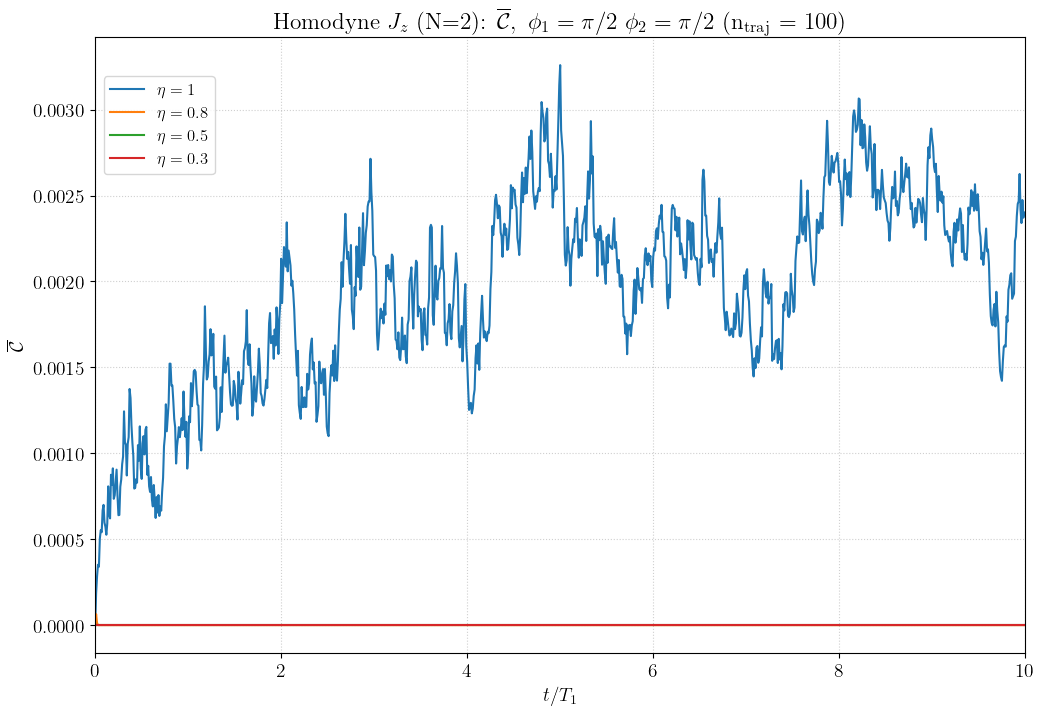

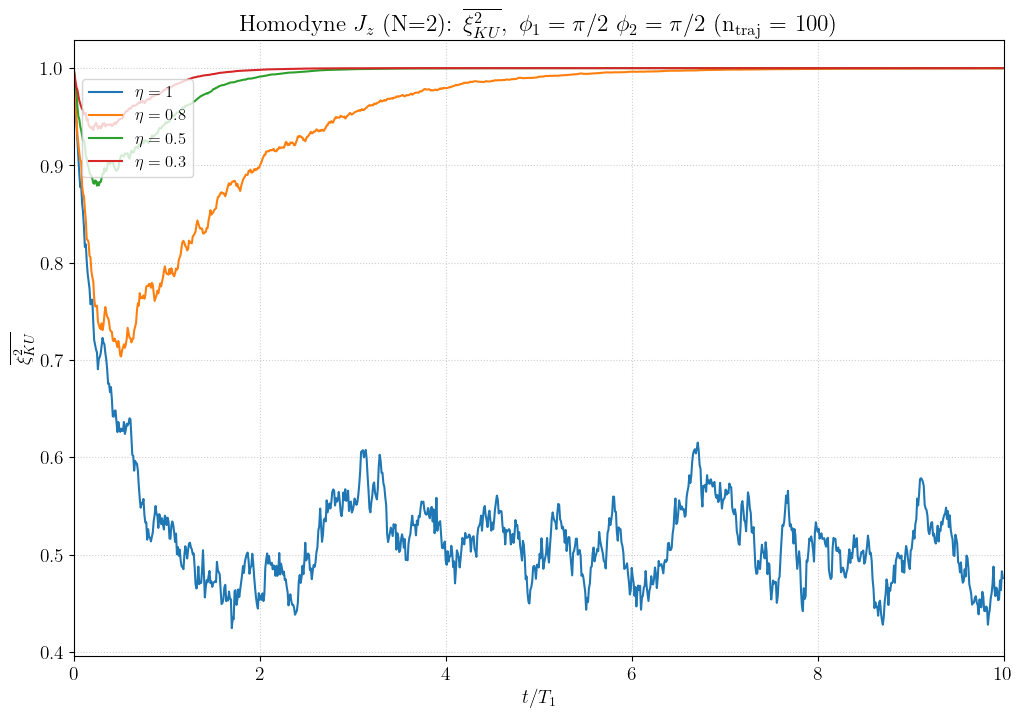

In [24]:
# PLOT + SAVE PDF
phi1_tex = angle_to_tex(float(phi1))
phi2_tex = angle_to_tex(float(phi2))

x = times / T1

for col in columns:
    plt.figure(figsize=(12, 8))

    for eta in etas:
        key = f"{eta:g}"
        y = ineff_df[key][col].to_numpy()
        line, = plt.plot(x, y, label=rf"$\eta = {eta:g}$")

        # if col == "Conc" and not no_theory:
        #     y_th = theoretical_concurrence_curve(
        #         times=times,
        #         gamma=gamma,
        #         eta=eta,
        #         theta=theta_for_theory,
        #     )
        #     plt.plot(
        #         x,
        #         y_th,
        #         "--",
        #         color=line.get_color(),
        #         alpha=0.55,
        #         linewidth=2,
        #     )

    plt.xlim(0.0, float(t_end))
    plt.xlabel(r"$t/T_1$")
    plt.ylabel(LABELS[col])
    plt.title(
        r"Homodyne $J_z$ (N=2): "
        + LABELS[col]
        + rf"$,\ \phi_1={phi1_tex}\ \phi_2={phi2_tex}$"
        + rf"  (n$_\mathrm{{traj}}$ = {ntraj})"
    )
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left", bbox_to_anchor=(0, 0.95), fontsize=12)
    plt.savefig(out_dir / f"Homodyne_{col}.pdf", bbox_inches="tight")
    plt.show()


In [16]:
# QUICK LOOK
ineff_df[f"{etas[0]:g}"].describe()


,Conc,Xi2_KU
count,1000.000000,1000.000000
mean,0.544372,0.452705
std,0.067620,0.063083
min,0.000000,0.424321
25%,0.558548,0.437508
50%,0.558674,0.440000
75%,0.561224,0.440001
max,0.574264,1.000000
